# Causal behavioral decoding for BSS-cleaned calcium traces

This notebook tests whether BSS-cleaned extracted traces preserve behavior-decodable structure from the raw extracted traces. The key comparisons are within-version decoding and transfer decoding between raw and cleaned trace representations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(p for p in candidates if (p / "pyproject.toml").exists() and (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from behavior_decoding import (
    load_trace_variants,
    make_behavior_targets,
    plot_behavior_trace_evidence,
)
from causal_behavior_decoding import (
    CausalStateConfig,
    fit_causal_state_model,
)

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
PROJECT_ROOT

PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising')

## Configuration

In [2]:
# Supervised behavior decoding is ONLY for v2a-RSNs datasets.
# Motorneurons remains an unsupervised-only analysis and must not be used here.
DATASET_GROUP = "v2a-RSNs"
DATA_NAME = "220127_F4_run2_fluorescence"
RAW_TRACE_CANDIDATES = [
    PROJECT_ROOT / "data" / DATASET_GROUP / "new_run2_844ROI" / "fluo_signals_no_NaN.npy",
    PROJECT_ROOT
    / "data"
    / DATASET_GROUP
    / "new_data_09112022"
    / "220127_F4_run2"
    / "220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy",
    PROJECT_ROOT
    / "data"
    / DATASET_GROUP
    / "new_data_09112022"
    / "220210_F1_run6"
    / "220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy",
]
RAW_TRACE_PATH = next((path for path in RAW_TRACE_CANDIDATES if path.exists()), None)
if RAW_TRACE_PATH is None:
    raise FileNotFoundError(
        "No supported v2a raw trace file found. Update RAW_TRACE_CANDIDATES in this cell."
    )
DATASET_DIR = RAW_TRACE_PATH.parent
RAW_NAME = RAW_TRACE_PATH.name

# Use the matching v2a tail-angle target only (no cross-dataset fallback).
TAIL_ANGLE_PATH = (
    PROJECT_ROOT
    / "data"
    / "v2a-RSNs"
    / "new_data_09112022"
    / "220127_F4_run2"
    / "220127_F4_F4_run2_after_dec_tail_angle.npy"
)
if not TAIL_ANGLE_PATH.exists():
    raise FileNotFoundError(
        f"Expected v2a tail-angle file not found: {TAIL_ANGLE_PATH}. "
        "Set TAIL_ANGLE_PATH to the matching v2a behavior recording before running."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "causal_behavior_decoding" / DATASET_GROUP / DATA_NAME
CLEANED_ROOT_CANDIDATES = [
    # Current canonical layout from clustering_methods.ipynb:
    # outputs/linear/<dataset_group>/<data_name>/<method>/cleaned/cleaned_*.npy
    PROJECT_ROOT / "outputs" / "linear" / DATASET_GROUP / DATA_NAME,
    # Legacy clustered layout kept for older saved runs.
    PROJECT_ROOT / "outputs" / "linear" / DATASET_GROUP / "clustered" / DATASET_GROUP / DATA_NAME,
    PROJECT_ROOT / "outputs" / "linear_v2a-RSNs_clustered" / DATASET_GROUP / DATA_NAME,
    PROJECT_ROOT / "outputs" / "clustered" / DATASET_GROUP / DATA_NAME,
    PROJECT_ROOT / "outputs" / "cleaned_timeseries" / "linear",
]
CLEANED_ROOT = next((path for path in CLEANED_ROOT_CANDIDATES if path.exists()), CLEANED_ROOT_CANDIDATES[0])

CLEANED_GLOB = "cleaned_*.npy"
METHOD_GLOB = "*"
# Optional strict method filter. Keep empty tuple () to include all discovered methods.
METHODS_TO_INCLUDE = ("fastica", "infomax", "sobi", "jade")
# When incremental variants are present, prefer them over canonical method-level cleaned files.
PREFER_INCREMENTAL_VARIANTS = True
INCREMENTAL_SELECTION_PREFIX = "keep_top_"
LAGS = (1, 2, 3, 5)
TARGET_SHIFT = 0
N_SPLITS = 5
GAP = 3
RIDGE_ALPHA = 10.0
BOUT_QUANTILE = 0.75
SMOOTH_WINDOW = 3

if not RAW_TRACE_PATH.exists():
    raise FileNotFoundError(
        f"Raw v2a trace file not found: {RAW_TRACE_PATH}. "
        "This notebook should only run when the matching v2a dataset is available."
    )

DATASET_DIR, TAIL_ANGLE_PATH, OUTPUT_DIR, CLEANED_ROOT


(PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/data/v2a-RSNs/new_data_09112022/220127_F4_run2'),
 PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/data/v2a-RSNs/new_data_09112022/220127_F4_run2/220127_F4_F4_run2_after_dec_tail_angle.npy'),
 PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/causal_behavior_decoding/v2a-RSNs/220127_F4_run2_fluorescence'),
 PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence'))

## Load raw and cleaned traces

In [3]:
variants = load_trace_variants(
    DATASET_DIR,
    raw_name=RAW_NAME,
    cleaned_glob=CLEANED_GLOB,
    cleaned_root=CLEANED_ROOT,
    dataset_name=DATA_NAME,
    method_glob=METHOD_GLOB,
)
if METHODS_TO_INCLUDE:
    keep = set(METHODS_TO_INCLUDE)
    variants = [
        v for v in variants if v.name == "raw" or v.name.split("/", 1)[0] in keep
    ]

raw_variants = [v for v in variants if v.name == "raw"]
if not raw_variants:
    raise ValueError("Raw trace variant was not found.")
raw_variant = raw_variants[0]
cleaned_variants = [v for v in variants if v.name != "raw"]

if PREFER_INCREMENTAL_VARIANTS:
    by_method = {}
    for variant in cleaned_variants:
        method_name = variant.name.split("/", 1)[0]
        by_method.setdefault(method_name, []).append(variant)

    preferred = []
    for method_name, method_variants in sorted(by_method.items()):
        incremental = [
            variant for variant in method_variants if f"/{INCREMENTAL_SELECTION_PREFIX}" in variant.name
        ]
        preferred.extend(incremental if incremental else method_variants)
    cleaned_variants = preferred


def _variant_sort_key(variant):
    parts = variant.name.split("/")
    method_name = parts[0] if parts else variant.name
    selection_id = (
        parts[1]
        if len(parts) >= 3 and parts[1].startswith(INCREMENTAL_SELECTION_PREFIX)
        else ""
    )
    clusters_kept = np.nan
    if selection_id:
        try:
            clusters_kept = int(selection_id.replace(INCREMENTAL_SELECTION_PREFIX, ""))
        except ValueError:
            clusters_kept = np.nan
    clusters_sort = int(clusters_kept) if np.isfinite(clusters_kept) else 10**9
    return (method_name, clusters_sort, variant.name)


cleaned_variants = sorted(cleaned_variants, key=_variant_sort_key)
variants = [raw_variant, *cleaned_variants]

if len(variants) < 2:
    raise ValueError(
        "No cleaned variants selected. Check CLEANED_ROOT and METHODS_TO_INCLUDE."
    )

trace_table = pd.DataFrame(
    {
        "version": [v.name for v in variants],
        "path": [str(v.path.relative_to(PROJECT_ROOT)) for v in variants],
        "shape": [v.traces.shape for v in variants],
    }
)
trace_table["method"] = trace_table["version"].map(
    lambda name: "raw" if name == "raw" else name.split("/", 1)[0]
)
trace_table["selection_id"] = trace_table["version"].map(
    lambda name: (
        name.split("/")[1]
        if name != "raw"
        and len(name.split("/")) >= 3
        and name.split("/")[1].startswith(INCREMENTAL_SELECTION_PREFIX)
        else None
    )
)
trace_table["clusters_kept"] = pd.to_numeric(
    trace_table["selection_id"].fillna("").str.replace(INCREMENTAL_SELECTION_PREFIX, "", regex=False),
    errors="coerce",
)
trace_table["is_incremental"] = trace_table["selection_id"].notna()
trace_table


,version,path,shape,method,selection_id,clusters_kept,is_incremental
0,raw,data/v2a-RSNs/new_data_09112022/220127_F4_run2...,"(3176, 844)",raw,NaN,NaN,False
1,fastica/keep_top_01/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_01,1.0,True
2,fastica/keep_top_02/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_02,2.0,True
3,fastica/keep_top_03/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_03,3.0,True
4,fastica/keep_top_04/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_04,4.0,True
5,fastica/keep_top_05/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_05,5.0,True
6,fastica/keep_top_06/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_06,6.0,True
7,infomax/keep_top_01/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_01,1.0,True
8,infomax/keep_top_02/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_02,2.0,True
9,infomax/keep_top_03/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_03,3.0,True


In [4]:
raw = variants[0].traces
trace_table

,version,path,shape,method,selection_id,clusters_kept,is_incremental
0,raw,data/v2a-RSNs/new_data_09112022/220127_F4_run2...,"(3176, 844)",raw,NaN,NaN,False
1,fastica/keep_top_01/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_01,1.0,True
2,fastica/keep_top_02/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_02,2.0,True
3,fastica/keep_top_03/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_03,3.0,True
4,fastica/keep_top_04/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_04,4.0,True
5,fastica/keep_top_05/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_05,5.0,True
6,fastica/keep_top_06/cleaned_fastica_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",fastica,keep_top_06,6.0,True
7,infomax/keep_top_01/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_01,1.0,True
8,infomax/keep_top_02/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_02,2.0,True
9,infomax/keep_top_03/cleaned_infomax_220127_F4_...,outputs/linear/v2a-RSNs/220127_F4_run2_fluores...,"(3176, 844)",infomax,keep_top_03,3.0,True


## Align tail behavior to calcium frames

In [5]:
tail_angle = np.load(TAIL_ANGLE_PATH)
targets = make_behavior_targets(
    tail_angle,
    n_frames=raw.shape[0],
    bout_quantile=BOUT_QUANTILE,
    smooth_window=SMOOTH_WINDOW,
)

pd.Series(
    {
        "tail_samples": tail_angle.shape[0],
        "calcium_frames": raw.shape[0],
        "samples_per_calcium_frame": tail_angle.shape[0] / raw.shape[0],
        "bout_threshold": targets.bout_threshold,
        "bout_fraction": targets.bout_state.mean(),
    }
)

tail_samples                 179997.000000
calcium_frames                 3176.000000
samples_per_calcium_frame        56.674118
bout_threshold                    1.431410
bout_fraction                     0.250000
dtype: float64

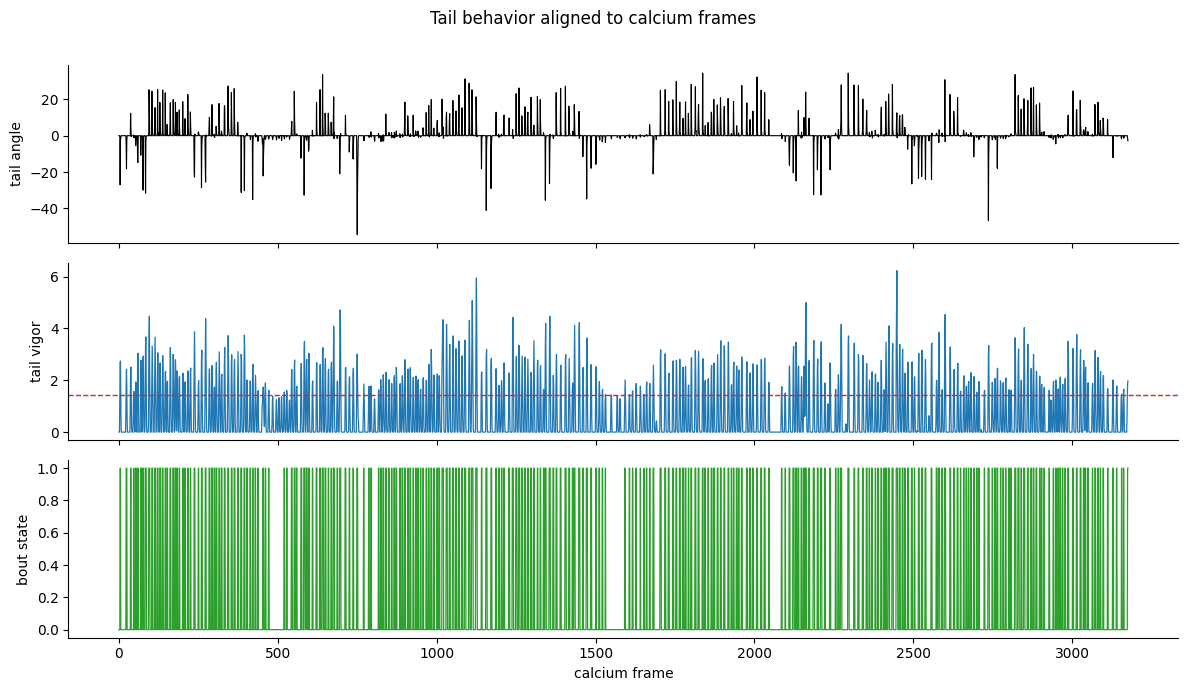

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
frames = np.arange(raw.shape[0])
axes[0].plot(frames, targets.angle, color="black", lw=0.8)
axes[0].set_ylabel("tail angle")
axes[1].plot(frames, targets.vigor, color="tab:blue", lw=0.9)
axes[1].axhline(targets.bout_threshold, color="tab:red", ls="--", lw=1)
axes[1].set_ylabel("tail vigor")
axes[2].plot(frames, targets.bout_state, color="tab:green", lw=0.9)
axes[2].set_ylabel("bout state")
axes[2].set_xlabel("calcium frame")
fig.suptitle("Tail behavior aligned to calcium frames")
fig.tight_layout(rect=(0, 0, 1, 0.97))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "tail_behavior_aligned_to_calcium_frames.png", dpi=300, bbox_inches="tight")
# fig

## Paper-ready trace and behavior evidence

This panel can be generated before running the decoding experiment. It selects a representative neuron by a stated rule and aligns raw/denoised traces to the behavior window with the strongest bout structure.

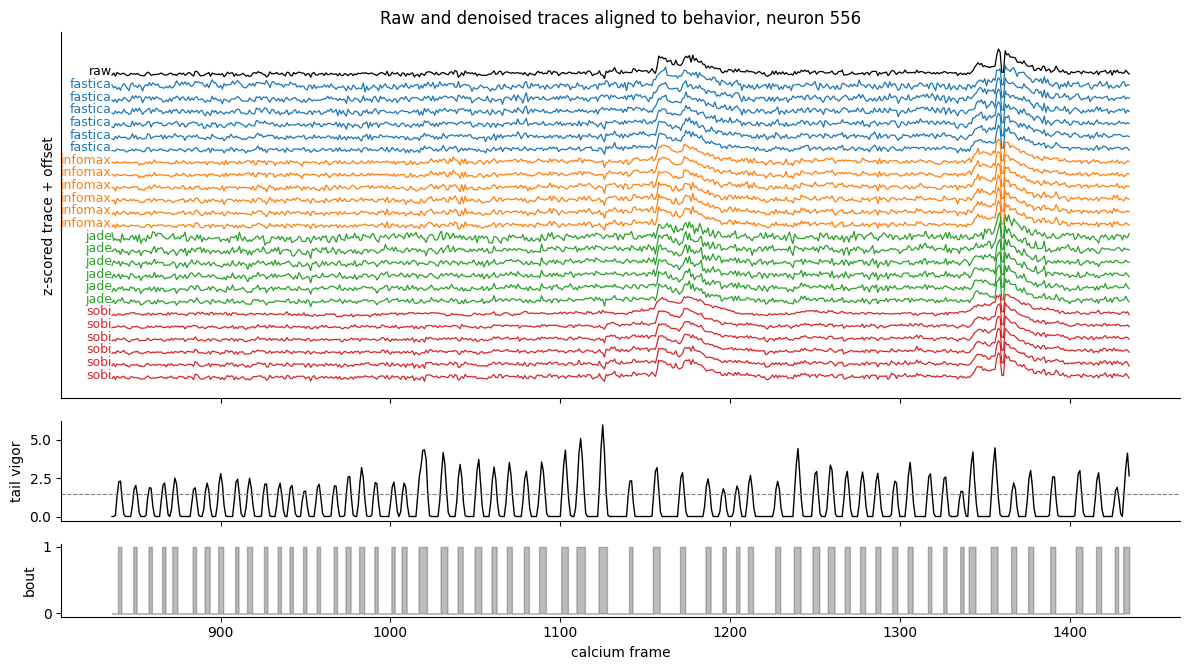

In [7]:
trace_evidence_fig, trace_evidence_axes = plot_behavior_trace_evidence(
    variants,
    targets,
    window_size=600,
)

## Run decoding experiments

In [8]:
causal_config = CausalStateConfig(
    window=15,
    target_shifts=(TARGET_SHIFT,),
    latent_dim=3,
    n_splits=N_SPLITS,
    gap=GAP,
    ridge_alpha=RIDGE_ALPHA,
    random_state=0,
)

causal_result = fit_causal_state_model(
    variants=variants,
    targets=targets,
    config=causal_config,
)

metrics = causal_result.fold_metrics.copy()
summary = (
    metrics.groupby(["variant", "target_shift"], dropna=False)
    .agg(
        dynamic_mse_mean=("dynamic_mse", "mean"),
        angle_r2_mean=("angle_r2", "mean"),
        angle_pearson_mean=("angle_pearson", "mean"),
        vigor_r2_mean=("vigor_r2", "mean"),
        vigor_pearson_mean=("vigor_pearson", "mean"),
        bout_balanced_accuracy_mean=("bout_balanced_accuracy", "mean"),
        bout_roc_auc_mean=("bout_roc_auc", "mean"),
    )
    .reset_index()
)
summary.head()

,variant,target_shift,dynamic_mse_mean,angle_r2_mean,angle_pearson_mean,vigor_r2_mean,vigor_pearson_mean,bout_balanced_accuracy_mean,bout_roc_auc_mean
0,fastica/keep_top_01/cleaned_fastica_220127_F4_...,0,5.782429,0.026704,0.177905,0.002046,0.079099,0.526412,0.533609
1,fastica/keep_top_02/cleaned_fastica_220127_F4_...,0,4.427953,0.033789,0.193088,0.006389,0.095504,0.532881,0.545715
2,fastica/keep_top_03/cleaned_fastica_220127_F4_...,0,3.551465,0.032786,0.190788,0.005839,0.093481,0.536482,0.543494
3,fastica/keep_top_04/cleaned_fastica_220127_F4_...,0,3.015736,0.032540,0.190927,0.004973,0.090064,0.530647,0.541355
4,fastica/keep_top_05/cleaned_fastica_220127_F4_...,0,2.510929,0.032043,0.189825,0.004466,0.087460,0.531110,0.540019


## Paper-ready decoding and preservation summary

Run this after the decoding experiment. It shows fold-level within-decoding, raw-to-denoised transfer, and the Behavioral Preservation Index used to rank methods.

,variant,corr_to_vigor_next,residual_vigor_corr
0,fastica/keep_top_01/cleaned_fastica_220127_F4_...,0.059971,0.007859
1,fastica/keep_top_02/cleaned_fastica_220127_F4_...,0.066869,0.004058
2,fastica/keep_top_03/cleaned_fastica_220127_F4_...,0.065107,0.015782
3,fastica/keep_top_04/cleaned_fastica_220127_F4_...,0.021027,0.045472
4,fastica/keep_top_05/cleaned_fastica_220127_F4_...,0.040837,0.074556
5,fastica/keep_top_06/cleaned_fastica_220127_F4_...,0.049435,0.086807
6,infomax/keep_top_01/cleaned_infomax_220127_F4_...,0.056701,0.107126
7,infomax/keep_top_02/cleaned_infomax_220127_F4_...,0.056742,0.110024
8,infomax/keep_top_03/cleaned_infomax_220127_F4_...,0.057245,0.108375
9,infomax/keep_top_04/cleaned_infomax_220127_F4_...,0.009628,0.096721


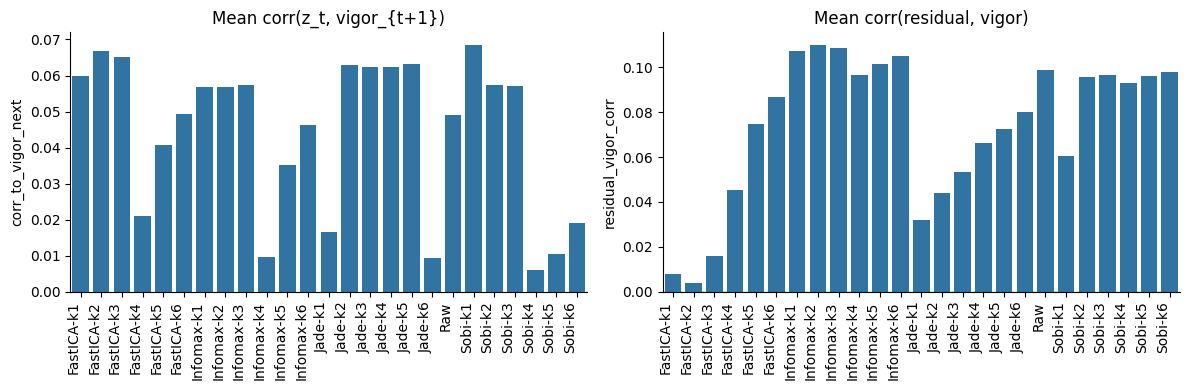

In [15]:
graph_summary = (
    causal_result.graph_metrics.groupby(["variant", "target_shift"], as_index=False)[
        ["corr_to_angle_next", "corr_to_vigor_next", "corr_to_bout_next"]
    ].mean()
)
resid_summary = (
    causal_result.residual_tests.groupby(["variant", "target_shift"], as_index=False)[
        ["residual_vigor_corr", "residual_bout_corr"]
    ].mean()
)
causal_diag = graph_summary.merge(resid_summary, on=["variant", "target_shift"], how="left")
def _short_variant_label(name: str) -> str:
    if name == "raw":
        return "Raw"
    parts = name.split("/")
    method = parts[0] if parts else name
    method_label = {
        "fastica": "FastICA",
        "infomax": "Infomax",
    }.get(method, method.replace("_", " ").title().replace(" ", ""))
    clusters_kept = np.nan
    if len(parts) >= 2 and parts[1].startswith(INCREMENTAL_SELECTION_PREFIX):
        clusters_kept = pd.to_numeric(
            parts[1].replace(INCREMENTAL_SELECTION_PREFIX, ""), errors="coerce"
        )
    if pd.notna(clusters_kept):
        return f"{method_label}-k{int(clusters_kept)}"
    return method_label

causal_diag["variant_label"] = causal_diag["variant"].map(_short_variant_label)

causal_diag_fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=causal_diag, x="variant_label", y="corr_to_vigor_next", estimator=np.mean, ax=axes[0])
axes[0].set_title("Mean corr(z_t, vigor_{t+1})")
axes[0].set_xlabel("")
axes[0].set_ylabel("corr_to_vigor_next")
sns.barplot(data=causal_diag, x="variant_label", y="residual_vigor_corr", estimator=np.mean, ax=axes[1])
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_title("Mean corr(residual, vigor)")
axes[1].set_xlabel("")
axes[1].set_ylabel("residual_vigor_corr")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=90)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("right")
causal_diag_fig.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
causal_diag_fig.savefig(OUTPUT_DIR / "causal_diagnostics_summary.png", dpi=300, bbox_inches="tight")
causal_diag.groupby("variant")[["corr_to_vigor_next", "residual_vigor_corr"]].mean().reset_index()


,metric,method,selection_id,clusters_kept,target_shift,score,delta_vs_prev,delta_vs_raw,variant,method_label,variant_label
0,bout_balanced_accuracy,fastica,keep_top_01,1.0,0,0.526412,NaN,0.001009,fastica/keep_top_01/cleaned_fastica_220127_F4_...,FastICA,FastICA-k1
1,bout_balanced_accuracy,fastica,keep_top_02,2.0,0,0.532881,0.006468,0.007477,fastica/keep_top_02/cleaned_fastica_220127_F4_...,FastICA,FastICA-k2
2,bout_balanced_accuracy,fastica,keep_top_03,3.0,0,0.536482,0.003601,0.011078,fastica/keep_top_03/cleaned_fastica_220127_F4_...,FastICA,FastICA-k3
3,bout_balanced_accuracy,fastica,keep_top_04,4.0,0,0.530647,-0.005835,0.005244,fastica/keep_top_04/cleaned_fastica_220127_F4_...,FastICA,FastICA-k4
4,bout_balanced_accuracy,fastica,keep_top_05,5.0,0,0.531110,0.000463,0.005706,fastica/keep_top_05/cleaned_fastica_220127_F4_...,FastICA,FastICA-k5
5,bout_balanced_accuracy,fastica,keep_top_06,6.0,0,0.530028,-0.001082,0.004624,fastica/keep_top_06/cleaned_fastica_220127_F4_...,FastICA,FastICA-k6
6,bout_balanced_accuracy,infomax,keep_top_01,1.0,0,0.525201,NaN,-0.000203,infomax/keep_top_01/cleaned_infomax_220127_F4_...,Infomax,Infomax-k1
7,bout_balanced_accuracy,infomax,keep_top_02,2.0,0,0.526965,0.001765,0.001562,infomax/keep_top_02/cleaned_infomax_220127_F4_...,Infomax,Infomax-k2
8,bout_balanced_accuracy,infomax,keep_top_03,3.0,0,0.527918,0.000953,0.002515,infomax/keep_top_03/cleaned_infomax_220127_F4_...,Infomax,Infomax-k3
9,bout_balanced_accuracy,infomax,keep_top_04,4.0,0,0.526254,-0.001665,0.000850,infomax/keep_top_04/cleaned_infomax_220127_F4_...,Infomax,Infomax-k4


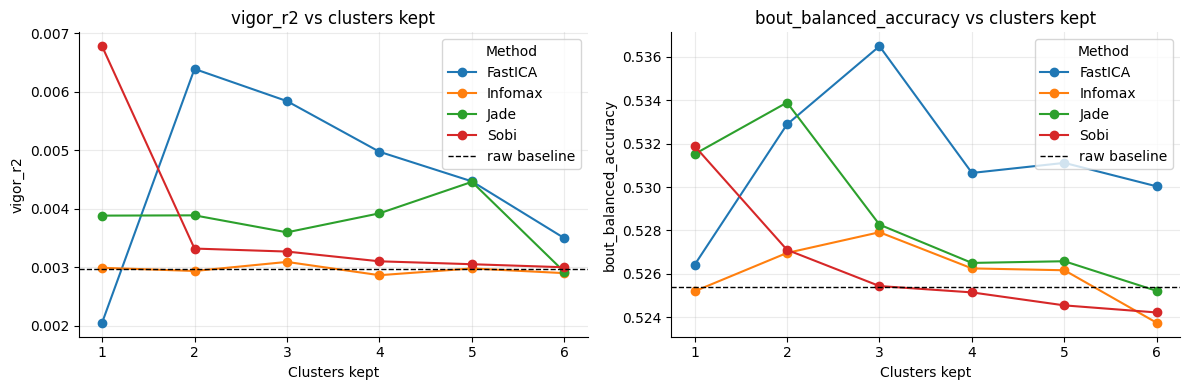

In [10]:
variant_meta = trace_table.rename(columns={"version": "variant"})[
    ["variant", "method", "selection_id", "clusters_kept", "is_incremental"]
].copy()

causal_summary_with_meta = summary.merge(variant_meta, on="variant", how="left")
metric_specs = [
    ("vigor_r2_mean", "vigor_r2"),
    ("bout_balanced_accuracy_mean", "bout_balanced_accuracy"),
]

progress_frames = []
for metric_column, metric_name in metric_specs:
    metric_df = causal_summary_with_meta[
        [
            "variant",
            "target_shift",
            "method",
            "selection_id",
            "clusters_kept",
            "is_incremental",
            metric_column,
        ]
    ].copy()
    metric_df = metric_df.rename(columns={metric_column: "score"})
    metric_df["metric"] = metric_name

    raw_scores = metric_df[metric_df["variant"] == "raw"][["target_shift", "score"]].rename(
        columns={"score": "raw_score"}
    )
    metric_df = metric_df[metric_df["is_incremental"]].merge(
        raw_scores,
        on="target_shift",
        how="left",
    )
    progress_frames.append(metric_df)

causal_cluster_progress = pd.concat(progress_frames, ignore_index=True) if progress_frames else pd.DataFrame()
if not causal_cluster_progress.empty:
    causal_cluster_progress = causal_cluster_progress.sort_values(
        ["metric", "method", "target_shift", "clusters_kept"]
    )
    causal_cluster_progress["delta_vs_prev"] = causal_cluster_progress.groupby(
        ["metric", "method", "target_shift"]
    )["score"].diff()
    causal_cluster_progress["delta_vs_raw"] = (
        causal_cluster_progress["score"] - causal_cluster_progress["raw_score"]
    )
    causal_cluster_progress = causal_cluster_progress[
        [
            "metric",
            "method",
            "selection_id",
            "clusters_kept",
            "target_shift",
            "score",
            "delta_vs_prev",
            "delta_vs_raw",
            "variant",
        ]
    ].reset_index(drop=True)
    method_label_map = {
        "fastica": "FastICA",
        "infomax": "Infomax",
    }
    causal_cluster_progress["method_label"] = causal_cluster_progress["method"].map(method_label_map).fillna(
        causal_cluster_progress["method"].str.replace("_", " ").str.title().str.replace(" ", "", regex=False)
    )
    causal_cluster_progress["variant_label"] = np.where(
        causal_cluster_progress["clusters_kept"].notna(),
        causal_cluster_progress["method_label"]
        + "-k"
        + causal_cluster_progress["clusters_kept"].astype(int).astype(str),
        causal_cluster_progress["method_label"],
    )

    causal_cluster_progress_fig, axes = plt.subplots(1, len(metric_specs), figsize=(6 * len(metric_specs), 4))
    if len(metric_specs) == 1:
        axes = [axes]

    for ax, (_, metric_name) in zip(axes, metric_specs):
        metric_rows = causal_cluster_progress[causal_cluster_progress["metric"] == metric_name]
        for _, group in metric_rows.groupby("method"):
            group = group.sort_values("clusters_kept")
            ax.plot(
                group["clusters_kept"],
                group["score"],
                marker="o",
                lw=1.5,
                label=group["method_label"].iloc[0],
            )

        # Baseline from summary (raw row, first target_shift).
        baseline_rows = causal_summary_with_meta[
            (causal_summary_with_meta["variant"] == "raw")
            & (causal_summary_with_meta["target_shift"] == TARGET_SHIFT)
        ]
        if not baseline_rows.empty:
            baseline_value = baseline_rows.iloc[0][
                "vigor_r2_mean" if metric_name == "vigor_r2" else "bout_balanced_accuracy_mean"
            ]
            if np.isfinite(baseline_value):
                ax.axhline(
                    baseline_value,
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    label="raw baseline",
                )

        ax.set_title(f"{metric_name} vs clusters kept")
        ax.set_xlabel("Clusters kept")
        ax.set_ylabel(metric_name)
        if not metric_rows.empty:
            ax.set_xticks(sorted(metric_rows["clusters_kept"].dropna().astype(int).unique()))
        ax.grid(alpha=0.25)
        ax.legend(title="Method", loc="best")

    causal_cluster_progress_fig.tight_layout()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    causal_cluster_progress_fig.savefig(
        OUTPUT_DIR / "causal_cluster_progression_summary.png",
        dpi=300,
        bbox_inches="tight",
    )
else:
    print(
        "No incremental keep-top variants detected. "
        "Run clustering_methods.ipynb incremental saves or disable PREFER_INCREMENTAL_VARIANTS."
    )

causal_cluster_progress


## Supplementary prediction traces for one fold

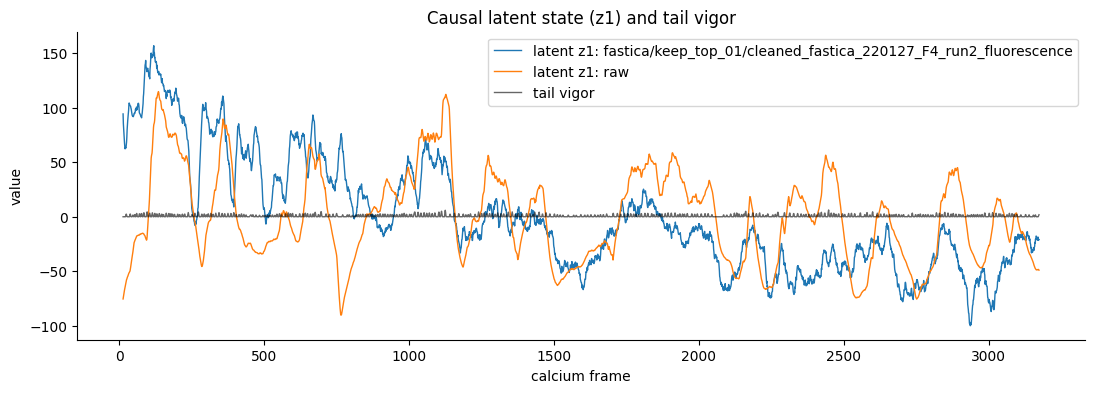

In [11]:
embeddings = causal_result.embeddings.copy()
example_version = variants[1].name if len(variants) > 1 else "raw"
plot_df = embeddings.query("variant in ['raw', @example_version]").sort_values("time_index")

fig, ax = plt.subplots(figsize=(13, 4))
for name, group in plot_df.groupby("variant"):
    ax.plot(group["time_index"], group["z1"], lw=1, label=f"latent z1: {name}")

truth = plot_df.drop_duplicates("time_index").sort_values("time_index")
ax.plot(truth["time_index"], truth["vigor"], color="black", lw=1.0, alpha=0.6, label="tail vigor")
ax.set_title("Causal latent state (z1) and tail vigor")
ax.set_xlabel("calcium frame")
ax.set_ylabel("value")
ax.legend();

## Save outputs

In [12]:
causal_result.fold_metrics.to_csv(OUTPUT_DIR / "causal_fold_metrics.csv", index=False)
summary.to_csv(OUTPUT_DIR / "causal_summary.csv", index=False)
causal_result.embeddings.to_csv(OUTPUT_DIR / "causal_embeddings.csv", index=False)
causal_result.graph_metrics.to_csv(OUTPUT_DIR / "causal_graph_metrics.csv", index=False)
causal_result.residual_tests.to_csv(OUTPUT_DIR / "causal_residual_tests.csv", index=False)
if "causal_cluster_progress" in globals() and isinstance(causal_cluster_progress, pd.DataFrame):
    causal_cluster_progress.to_csv(OUTPUT_DIR / "causal_cluster_progression_summary.csv", index=False)

if "trace_evidence_fig" in globals():
    trace_evidence_fig.savefig(OUTPUT_DIR / "paper_trace_behavior_evidence.png", dpi=300, bbox_inches="tight")
if "causal_diag_fig" in globals():
    causal_diag_fig.savefig(OUTPUT_DIR / "paper_causal_diagnostics_summary.png", dpi=300, bbox_inches="tight")
if "causal_cluster_progress_fig" in globals():
    causal_cluster_progress_fig.savefig(OUTPUT_DIR / "paper_causal_cluster_progression_summary.png", dpi=300, bbox_inches="tight")

OUTPUT_DIR


PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/causal_behavior_decoding/v2a-RSNs/220127_F4_run2_fluorescence')